<a href="https://colab.research.google.com/github/ethan-wood-uk/APRR-Concession-Model/blob/main/APRR_Concession_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# APRR Motorway Concession — Project Finance Model

## Background

APRR (Autoroutes Paris-Rhin-Rhône) is one of France's largest motorway concession
operators, holding the right to collect tolls on approximately 2,323 km of motorway
in eastern France until November 2035, when the network reverts to the French State.

In February 2006, a consortium of Macquarie and Eiffage acquired 81.5% of APRR from
the French government as part of a broader motorway privatisation programme.

This model is built as if at the point of that acquisition — assessing what return
an investor could expect to earn over the remaining concession life, given assumptions
about traffic growth, inflation, and financing structure.

## Section 1 — Assumptions and Inputs

All model inputs are defined here in one place. Inputs grounded in published data or
market convention are noted as such. Forward assumptions are anchored to historical
ranges where possible. Items marked DATA NEEDED require extraction from the 2005 APRR
annual report before the model produces meaningful outputs.

In [2]:
!pip install numpy_financial

In [3]:
import numpy as np
import pandas as pd
import numpy_financial as npf
import matplotlib.pyplot as plt
from datetime import date

# ── TIMING ──────────────────────────────────────────────────
ACQUISITION_DATE    = date(2006, 2, 1)   # Real transaction date
CONCESSION_END_DATE = date(2035, 11, 30) # Confirmed: concession agreement
PERIODS_PER_YEAR    = 2                  # Semi-annual model

concession_years = (CONCESSION_END_DATE - ACQUISITION_DATE).days / 365.25
N_PERIODS = int(concession_years * PERIODS_PER_YEAR)

print(f"Concession life: {concession_years:.1f} years | Semi-annual periods: {N_PERIODS}")

Concession life: 29.8 years | Semi-annual periods: 59


In [4]:
# ── NETWORK AND TRAFFIC ──────────────────────────────────────
# Network length confirmed from APRR published data (APRR + AREA combined)
NETWORK_LENGTH_KM = 2323

# Initial volumes: to be extracted from 2005 APRR annual report
INITIAL_LIGHT_VEH_PER_DAY = 600000   # DATA NEEDED — 2005 annual report
INITIAL_HEAVY_VEH_PER_DAY = 80000    # DATA NEEDED — 2005 annual report

# Growth rates: forward assumptions anchored to APRR pre-2006 historical growth
# Light vehicles historically ~1.5-3.0% p.a.; heavy ~0.5-2.0% p.a.
# Monte Carlo will vary both across plausible ranges
LIGHT_VEH_GROWTH_RATE_PA = 0.020  # Base case: 2.0% p.a.
HEAVY_VEH_GROWTH_RATE_PA = 0.015  # Base case: 1.5% p.a.

In [5]:
# ── TOLLS, OPEX AND INFLATION ────────────────────────────────
# Toll rates: published and regulated; to be extracted from 2005 tariff schedules
# Simplified to one weighted average rate per vehicle class
INITIAL_TOLL_LIGHT_EUR_PER_VEH = 3.5  # DATA NEEDED — 2005 tariff schedule
INITIAL_TOLL_HEAVY_EUR_PER_VEH = 10 # DATA NEEDED — 2005 tariff schedule

# Opex: fixed per km and variable per vehicle; to be extracted from 2005 accounts
# Major maintenance ~€150m p.a. across network (APRR published)
FIXED_OPEX_EUR_PER_KM_PA  = 64572   # DATA NEEDED ~€150m total / 2,323 km
VARIABLE_OPEX_EUR_PER_VEH = 0.3   # DATA NEEDED — 2005 accounts

# Inflation: French CPI ~1.7-1.9% in 2006; base case uses ECB 2% target
# Tolls and opex both assumed to escalate at CPI — simplification
# Monte Carlo will vary inflation across plausible ranges
CPI_RATE_PA             = 0.020  # Base case: anchored to 2006 ECB target
TOLL_ESCALATION_RATE_PA = CPI_RATE_PA
OPEX_INFLATION_RATE_PA  = CPI_RATE_PA

# Working capital: standard terms for a regulated infrastructure asset
RECEIVABLES_DAYS = 30  # Electronic toll collection — short cycle
PAYABLES_DAYS    = 60  # Standard supplier terms

In [6]:
# ── TAX, FINANCING AND VALUATION ─────────────────────────────
# Tax: French corporate rate 2006 was 33.33%
# Depreciation/Amortisation: acquisition price treated as concession intangible,
# amortised straight-line over remaining concession life (simplification —
# full purchase price allocation not modelled; noted in README limitations)
CORPORATE_TAX_RATE = 0.3333
AMORTISATION_YEARS = concession_years

# Debt: terms consistent with 2006 European investment-grade infra acquisition
# APRR was A-rated at acquisition; interest rate anchored to 2006 Euribor + spread
DSCR_MINIMUM     = 1.35   # Market convention for toll road acquisition
MAX_DEBT_TO_COST = 0.80   # 80% LTV cap — market convention
DEBT_TENOR_YEARS = 15     # Standard tenor for investment-grade infra
INTEREST_RATE_PA = 0.045  # ~4.5% all-in (Euribor ~3.5-4% + spread)
ARRANGEMENT_FEE  = 0.010  # 1% upfront fee — market convention

# Valuation: core brownfield infra target return in 2006 was 8-10% equity IRR
# Model solves for acquisition price at target IRR and validates against
# actual 2006 transaction enterprise value
TARGET_EQUITY_IRR     = 0.080  # Conservative floor: 8.0%
ACQUISITION_PRICE_EUR = 7500000000      # DATA NEEDED — 2006 transaction EV

In [7]:
# ── INPUT SUMMARY ────────────────────────────────────────────
print(f"{'APRR ACQUISITION MODEL — INPUT SUMMARY':^55}")
print("=" * 55)
print(f"Concession life:        {concession_years:.1f} yrs | Periods: {N_PERIODS}")
print(f"Network:                {NETWORK_LENGTH_KM:,} km")
print(f"Light veh/day (2005):   {INITIAL_LIGHT_VEH_PER_DAY:,}  [DATA NEEDED]")
print(f"Heavy veh/day (2005):   {INITIAL_HEAVY_VEH_PER_DAY:,}  [DATA NEEDED]")
print(f"Light growth:           {LIGHT_VEH_GROWTH_RATE_PA:.1%} p.a.")
print(f"Heavy growth:           {HEAVY_VEH_GROWTH_RATE_PA:.1%} p.a.")
print(f"Light toll rate:        €{INITIAL_TOLL_LIGHT_EUR_PER_VEH:.2f}/veh  [DATA NEEDED]")
print(f"Heavy toll rate:        €{INITIAL_TOLL_HEAVY_EUR_PER_VEH:.2f}/veh  [DATA NEEDED]")
print(f"Fixed opex:             €{FIXED_OPEX_EUR_PER_KM_PA:,.0f}/km/yr  [DATA NEEDED]")
print(f"Variable opex:          €{VARIABLE_OPEX_EUR_PER_VEH:.2f}/veh  [DATA NEEDED]")
print(f"CPI / escalation:       {CPI_RATE_PA:.1%} p.a.")
print(f"Receivables / payables: {RECEIVABLES_DAYS}d / {PAYABLES_DAYS}d")
print(f"Corporate tax:          {CORPORATE_TAX_RATE:.2%}")
print(f"Amortisation life:      {AMORTISATION_YEARS:.1f} yrs")
print(f"DSCR minimum:           {DSCR_MINIMUM:.2f}x")
print(f"Max LTV:                {MAX_DEBT_TO_COST:.0%}")
print(f"Debt tenor:             {DEBT_TENOR_YEARS} yrs")
print(f"Interest rate:          {INTEREST_RATE_PA:.2%} p.a.")
print(f"Arrangement fee:        {ARRANGEMENT_FEE:.1%}")
print(f"Target equity IRR:      {TARGET_EQUITY_IRR:.1%}")
print(f"Acquisition price:      €{ACQUISITION_PRICE_EUR:,.0f}  [DATA NEEDED]")
print("=" * 55)

        APRR ACQUISITION MODEL — INPUT SUMMARY         
Concession life:        29.8 yrs | Periods: 59
Network:                2,323 km
Light veh/day (2005):   600,000  [DATA NEEDED]
Heavy veh/day (2005):   80,000  [DATA NEEDED]
Light growth:           2.0% p.a.
Heavy growth:           1.5% p.a.
Light toll rate:        €3.50/veh  [DATA NEEDED]
Heavy toll rate:        €10.00/veh  [DATA NEEDED]
Fixed opex:             €64,572/km/yr  [DATA NEEDED]
Variable opex:          €0.30/veh  [DATA NEEDED]
CPI / escalation:       2.0% p.a.
Receivables / payables: 30d / 60d
Corporate tax:          33.33%
Amortisation life:      29.8 yrs
DSCR minimum:           1.35x
Max LTV:                80%
Debt tenor:             15 yrs
Interest rate:          4.50% p.a.
Arrangement fee:        1.0%
Target equity IRR:      8.0%
Acquisition price:      €7,500,000,000  [DATA NEEDED]


## Section 2 — Operating Model

This section builds the core cash flow engine of the model. Starting from initial
traffic volumes and toll rates, it computes revenue, operating costs, and CFADS
(Cash Flow Available for Debt Service) across all 59 semi-annual periods to 2035.

In [8]:
# ── SECTION 2: OPERATING MODEL ───────────────────────────────
# ── 2.1 Timeline ─────────────────────────────────────────────

periods = np.arange(N_PERIODS)
days_per_period = 365.25 / 2
years_elapsed = periods / PERIODS_PER_YEAR

# ── 2.2 Inflation Index ───────────────────────────────────────
# Compounds CPI semi-annually from acquisition date
# Used to escalate both toll rates and opex each period

inflation_index = (1 + CPI_RATE_PA) ** years_elapsed

# ── 2.3 Traffic Volumes ───────────────────────────────────────
# Daily volumes compounded annually from initial 2005 figures
# Converted to per-period volumes using days_per_period

traffic_light = INITIAL_LIGHT_VEH_PER_DAY * (1 + LIGHT_VEH_GROWTH_RATE_PA) ** years_elapsed * days_per_period
traffic_heavy = INITIAL_HEAVY_VEH_PER_DAY * (1 + HEAVY_VEH_GROWTH_RATE_PA) ** years_elapsed * days_per_period

# ── 2.4 Inflated Toll Rates ───────────────────────────────────
# Real toll rates escalated by inflation index each period
# Simplified to one weighted average rate per vehicle class

toll_light = INITIAL_TOLL_LIGHT_EUR_PER_VEH * inflation_index
toll_heavy = INITIAL_TOLL_HEAVY_EUR_PER_VEH * inflation_index

In [9]:
# ── 2.5 Revenue ───────────────────────────────────────────────
# Total revenue per period = traffic × inflated toll rate
# Summed across light and heavy vehicle classes

revenue_light = traffic_light * toll_light
revenue_heavy = traffic_heavy * toll_heavy
total_revenue = revenue_light + revenue_heavy

In [10]:
# ── 2.6 Operating Expenditure ─────────────────────────────────
# Fixed opex: cost per km per year, converted to per-period, inflation-linked
# Variable opex: cost per vehicle, inflation-linked

opex_fixed    = FIXED_OPEX_EUR_PER_KM_PA * NETWORK_LENGTH_KM * (1 / PERIODS_PER_YEAR) * inflation_index
opex_variable = VARIABLE_OPEX_EUR_PER_VEH * (traffic_light + traffic_heavy) * inflation_index
total_opex    = opex_fixed + opex_variable

In [11]:
 # ── 2.7 EBITDA ────────────────────────────────────────────────
ebitda = total_revenue - total_opex

In [12]:
# ── 2.8 Working Capital ───────────────────────────────────────
# Change in net working capital each period
# Receivables increase as revenue grows — cash lags revenue slightly
# Payables increase as opex grows — cash lags payments slightly

receivables = total_revenue * (RECEIVABLES_DAYS / 365.25)
payables    = total_opex * (PAYABLES_DAYS / 365.25)
nwc         = receivables - payables
delta_nwc   = np.diff(nwc, prepend=nwc[0])

In [13]:
# ── 2.9 CFADS ─────────────────────────────────────────────────
# Cash Flow Available for Debt Service
# EBITDA less change in working capital
# Tax deducted in Section 3 after interest is known

cfads_pretax = ebitda - delta_nwc

## Section 3 — Debt Structure and Equity Returns

With pre-tax operating cash flows established, this section sizes the acquisition
debt, computes interest and tax, and produces the true CFADS available for debt
service. The equity cash flow and IRR follow from the residual after debt service.

The key challenge here is circularity: debt size drives interest, interest drives
tax, tax drives CFADS, and CFADS drives debt size. This is resolved through an
iterative convergence loop — a clean Python solution to a problem that requires
macros or add-ins in Excel.

In [14]:
# ── 3.1 Debt Sizing — Convergence Loop ───────────────────────
# Resolves circularity: debt → interest → tax → CFADS → debt
# Iterates until debt estimate stabilises (convergence)

DEBT_PERIODS = int(DEBT_TENOR_YEARS * PERIODS_PER_YEAR)  # 30 semi-annual periods
r = INTEREST_RATE_PA / PERIODS_PER_YEAR                  # Semi-annual interest rate

# Convergence loop
debt_estimate = 0
for _ in range(50):

    # Interest on outstanding debt (simplified: flat on opening balance)
    annual_interest = debt_estimate * INTEREST_RATE_PA

    # Depreciation — concession intangible amortised over concession life
    annual_amortisation = debt_estimate / AMORTISATION_YEARS

    # Taxable income and tax
    ebt        = ebitda - annual_amortisation - annual_interest
    tax        = np.maximum(ebt, 0) * CORPORATE_TAX_RATE

    # True CFADS after tax
    cfads      = cfads_pretax - tax

    # Size debt from CFADS during debt tenor only
    cfads_debt_period = cfads[:DEBT_PERIODS]
    debt_service  = cfads_debt_period / DSCR_MINIMUM
    new_debt      = np.npv(r, debt_service) if hasattr(np, 'npv') else npf.npv(r, debt_service)

    # Apply LTV cap
    new_debt = min(new_debt, ACQUISITION_PRICE_EUR * MAX_DEBT_TO_COST)

    # Check convergence
    if abs(new_debt - debt_estimate) < 1:
        break
    debt_estimate = new_debt

DEBT = debt_estimate
print(f"Debt sized at: €{DEBT:,.0f}")
print(f"Iterations to converge: {_+1}")

Debt sized at: €6,000,000,000
Iterations to converge: 2


In [15]:
#3.2 taxation and true CFADS based on DEBT

amortisation = np.full(N_PERIODS, ACQUISITION_PRICE_EUR / AMORTISATION_YEARS / PERIODS_PER_YEAR)
ebt          = ebitda - amortisation - (DEBT * INTEREST_RATE_PA / PERIODS_PER_YEAR)
tax          = np.maximum(ebt, 0) * CORPORATE_TAX_RATE
cfads        = cfads_pretax - tax

print(f"Amortisation per period: €{amortisation[0]:,.0f}")
print(f"EBT period 0:            €{ebt[0]:,.0f}")
print(f"Tax period 0:            €{tax[0]:,.0f}")
print(f"CFADS period 0:          €{cfads[0]:,.0f}")
print(f"CFADS period 58:         €{cfads[58]:,.0f}")


Amortisation per period: €125,728,612
EBT period 0:            €156,628,010
Tax period 0:            €52,204,116
CFADS period 0:          €365,152,506
CFADS period 58:         €991,791,160


In [16]:
# 3.3 Debt Service Schedule

# Start with all zeros — periods outside debt tenor stay zero
debt_service = np.zeros(N_PERIODS)

# Fill only the active debt periods (0-29) with sculpted debt service
# Sculpted = sized so CFADS / debt_service = DSCR_MINIMUM exactly each period
debt_service[:DEBT_PERIODS] = cfads[:DEBT_PERIODS] / DSCR_MINIMUM

# Initialise interest and balance arrays with zeros
# Balance needs one extra slot for the closing balance of the final period
interest   = np.zeros(N_PERIODS)
balance    = np.zeros(N_PERIODS + 1)
balance[0] = DEBT  # Opening balance = full debt amount

# Loop through active debt periods only
# Each period: calculate interest on opening balance, then reduce balance by repayment
for i in range(DEBT_PERIODS):
    # Interest = opening balance × semi-annual rate (declining as balance falls)
    interest[i] = balance[i] * r

    # Repayment = debt service minus interest (the principal reduction portion)
    # Capped at remaining balance to prevent overpayment
    repayment = min(debt_service[i] - interest[i], balance[i])

    # Closing balance = opening balance minus repayment
    # max(..., 0) prevents rounding errors pushing balance below zero
    balance[i+1] = max(balance[i] - repayment, 0)

# DSCR = CFADS / debt service, but only where debt service is positive
# NaN returned for periods 30-58 where there is no debt — division by zero avoided

# Replace zeros with 1 temporarily to avoid division warning
# np.where then discards these results anyway — purely to silence the warning

safe_debt_service = np.where(debt_service > 0, debt_service, 1)
dscr = np.where(debt_service > 0, cfads / safe_debt_service, np.nan)

In [17]:
# 3.3 Equity cash flows
equity_cf = np.zeros(N_PERIODS)  # array of zeros to start
equity_cf[0] = -(ACQUISITION_PRICE_EUR - DEBT)  # negative equity invested
equity_cf[1:] = cfads[1:] - debt_service[1:]  # CFADS minus debt service for all other periods

# IRR
semi_annual_irr = npf.irr(equity_cf)
annual_irr = (1 + semi_annual_irr) ** 2 - 1 # your compounding formula above

print(f"Equity IRR: {annual_irr:.2%}")

Equity IRR: 20.52%


In [18]:
print(f"Acquisition price:      €{ACQUISITION_PRICE_EUR:,.0f}")
print(f"Debt raised:            €{DEBT:,.0f}")
print(f"Equity invested:        €{ACQUISITION_PRICE_EUR - DEBT:,.0f}")
print(f"CFADS period 0:         €{cfads[0]:,.0f}")
print(f"CFADS period 58:        €{cfads[58]:,.0f}")
print(f"Debt service period 0:  €{debt_service[0]:,.0f}")
print(f"Equity CF period 0:     €{equity_cf[0]:,.0f}")
print(f"Equity CF period 1:     €{equity_cf[1]:,.0f}")
print(f"Equity CF period 58:    €{equity_cf[58]:,.0f}")
print(f"Semi-annual IRR:        {semi_annual_irr:.2%}")
print(f"Annual IRR:             {annual_irr:.2%}")

Acquisition price:      €7,500,000,000
Debt raised:            €6,000,000,000
Equity invested:        €1,500,000,000
CFADS period 0:         €365,152,506
CFADS period 58:        €991,791,160
Debt service period 0:  €270,483,338
Equity CF period 0:     €-1,500,000,000
Equity CF period 1:     €96,026,201
Equity CF period 58:    €991,791,160
Semi-annual IRR:        9.78%
Annual IRR:             20.52%


## Section 4 — Monte Carlo Simulation

The base case model produces a single deterministic IRR. In practice, traffic
growth, inflation, and financing costs over a 29-year concession life are uncertain.
This section runs 10,000 simulations, drawing each uncertain input from a normal
distribution centred on the base case, to produce a distribution of equity returns
rather than a point estimate.

Inputs varied: light and heavy vehicle growth rates, CPI, and all-in cost of debt.
Fixed inputs — acquisition price, network length, concession life, financing structure
— are held constant across simulations.

Note: inputs are drawn independently. In practice, inflation and interest rates are
correlated — a limitation discussed in Section 7.

In [19]:

# 4.1 Defining run_model function for monte carlo simulation

def run_model(light_growth, heavy_growth, cpi, interest_rate):

    # ── SECTION 2: OPERATING MODEL ───────────────────────────
    periods         = np.arange(N_PERIODS)
    days_per_period = 365.25 / 2
    years_elapsed   = periods / PERIODS_PER_YEAR
    inflation_index = (1 + cpi) ** years_elapsed
    traffic_light   = INITIAL_LIGHT_VEH_PER_DAY * (1 + light_growth) ** years_elapsed * days_per_period
    traffic_heavy   = INITIAL_HEAVY_VEH_PER_DAY * (1 + heavy_growth) ** years_elapsed * days_per_period
    toll_light      = INITIAL_TOLL_LIGHT_EUR_PER_VEH * inflation_index
    toll_heavy      = INITIAL_TOLL_HEAVY_EUR_PER_VEH * inflation_index
    revenue_light   = traffic_light * toll_light
    revenue_heavy   = traffic_heavy * toll_heavy
    total_revenue   = revenue_light + revenue_heavy
    opex_fixed      = FIXED_OPEX_EUR_PER_KM_PA * NETWORK_LENGTH_KM * (1 / PERIODS_PER_YEAR) * inflation_index
    opex_variable   = VARIABLE_OPEX_EUR_PER_VEH * (traffic_light + traffic_heavy) * inflation_index
    total_opex      = opex_fixed + opex_variable
    ebitda          = total_revenue - total_opex
    receivables     = total_revenue * (RECEIVABLES_DAYS / 365.25)
    payables        = total_opex * (PAYABLES_DAYS / 365.25)
    nwc             = receivables - payables
    delta_nwc       = np.diff(nwc, prepend=nwc[0])
    cfads_pretax    = ebitda - delta_nwc
    DEBT_PERIODS    = int(DEBT_TENOR_YEARS * PERIODS_PER_YEAR)
    r               = interest_rate / PERIODS_PER_YEAR

    # ── 3.1 Debt Sizing Convergence Loop ─────────────────────
    debt_estimate = 0
    for _ in range(50):
        annual_interest     = debt_estimate * interest_rate
        annual_amortisation = debt_estimate / AMORTISATION_YEARS
        ebt          = ebitda - annual_amortisation - annual_interest
        tax          = np.maximum(ebt, 0) * CORPORATE_TAX_RATE
        cfads        = cfads_pretax - tax
        debt_service = cfads[:DEBT_PERIODS] / DSCR_MINIMUM
        new_debt     = npf.npv(r, debt_service)
        new_debt     = min(new_debt, ACQUISITION_PRICE_EUR * MAX_DEBT_TO_COST)
        if abs(new_debt - debt_estimate) < 1:
            break
        debt_estimate = new_debt
    DEBT = debt_estimate

    # ── 3.2 Tax and True CFADS ───────────────────────────────
    amortisation = np.full(N_PERIODS, ACQUISITION_PRICE_EUR / AMORTISATION_YEARS / PERIODS_PER_YEAR)
    ebt          = ebitda - amortisation - (DEBT * interest_rate / PERIODS_PER_YEAR)
    tax          = np.maximum(ebt, 0) * CORPORATE_TAX_RATE
    cfads        = cfads_pretax - tax

    # ── 3.3 Debt Service Schedule ────────────────────────────
    debt_service        = np.zeros(N_PERIODS)
    debt_service[:DEBT_PERIODS] = cfads[:DEBT_PERIODS] / DSCR_MINIMUM
    interest            = np.zeros(N_PERIODS)
    balance             = np.zeros(N_PERIODS + 1)
    balance[0]          = DEBT

    for i in range(DEBT_PERIODS):
        interest[i]  = balance[i] * r
        repayment    = min(debt_service[i] - interest[i], balance[i])
        balance[i+1] = max(balance[i] - repayment, 0)

    safe_debt_service = np.where(debt_service > 0, debt_service, 1)
    dscr = np.where(debt_service > 0, cfads / safe_debt_service, np.nan)
    min_dscr = np.nanmin(dscr)

    # ── 3.4 Equity Cash Flows and IRR ───────────────────────
    equity_cf    = np.zeros(N_PERIODS)
    equity_cf[0] = -(ACQUISITION_PRICE_EUR - DEBT)
    equity_cf[1:] = cfads[1:] - debt_service[1:]

    semi_annual_irr = npf.irr(equity_cf)
    annual_irr      = (1 + semi_annual_irr) ** 2 - 1
    equity_multiple = np.sum(equity_cf[equity_cf > 0]) / abs(equity_cf[0])

    return annual_irr, min_dscr, equity_multiple

    return annual_irr, min_dscr


base_irr, base_dscr, base_moic = run_model(
    LIGHT_VEH_GROWTH_RATE_PA,
    HEAVY_VEH_GROWTH_RATE_PA,
    CPI_RATE_PA,
    INTEREST_RATE_PA
)
print(f"Base case IRR:      {base_irr:.2%}")
print(f"Base case min DSCR: {base_dscr:.2f}x")
print(f"Base case MOIC:     {base_moic:.2f}x")
print(f"Section 3 IRR:      {annual_irr:.2%}")
print(f"Match: {abs(base_irr - annual_irr) < 0.0001}")

Base case IRR:      20.52%
Base case min DSCR: 1.35x
Base case MOIC:     17.42x
Section 3 IRR:      20.52%
Match: True


In [20]:
# ── 4.2 Monte Carlo Simulation ───────────────────────────────
# 10,000 iterations varying key uncertain inputs simultaneously
# Each iteration draws random values from normal distributions
# centred on base case assumptions

N_SIMULATIONS = 10000
results = []

for _ in range(N_SIMULATIONS):
    # Draw random inputs — normal distribution centred on base case
    # Second argument is standard deviation — controls width of uncertainty range
    light_growth = np.random.normal(LIGHT_VEH_GROWTH_RATE_PA, 0.010)
    heavy_growth = np.random.normal(HEAVY_VEH_GROWTH_RATE_PA, 0.010)
    cpi          = np.random.normal(CPI_RATE_PA, 0.008)
    interest     = np.random.normal(INTEREST_RATE_PA, 0.007)

    try:
        # Run the full model with this iteration's random inputs
        # try block catches any errors without crashing the whole simulation
        output   = run_model(light_growth, heavy_growth, cpi, interest)
        irr      = output[0]
        min_dscr = output[1]
        equity_mult = output[2]

        # Only store result if IRR is a valid number
        # npf.irr occasionally returns nan for extreme input combinations
        if not np.isnan(irr):
            results.append((irr, min_dscr,equity_mult))

    except:
        # If the model fails for any reason on this iteration, skip it silently
        # pass means "do nothing and continue to the next iteration"
       pass

print(f"Valid simulations: {len(results)} of {N_SIMULATIONS}")

# Extract IRR and min DSCR into separate flat lists for plotting
# r[0] is the IRR and r[1] is the min DSCR from each stored tuple
irrs      = [r[0] for r in results]
min_dscrs = [r[1] for r in results]
eq_multiples = [r[2] for r in results]

print(f"Simulations complete: {N_SIMULATIONS:,}")
print(f"Mean IRR:    {np.mean(irrs):.2%}")
print(f"Median IRR:  {np.median(irrs):.2%}")
print(f"10th pctile: {np.percentile(irrs, 10):.2%}")
print(f"90th pctile: {np.percentile(irrs, 90):.2%}")

Valid simulations: 10000 of 10000
Simulations complete: 10,000
Mean IRR:    20.57%
Median IRR:  20.56%
10th pctile: 19.03%
90th pctile: 22.09%


In [21]:
# Diagnostic — check function output before running Monte Carlo
test = run_model(LIGHT_VEH_GROWTH_RATE_PA, HEAVY_VEH_GROWTH_RATE_PA, CPI_RATE_PA, INTEREST_RATE_PA)
print(f"Number of return values: {len(test)}")
print(f"Values: {test}")

Number of return values: 3
Values: (0.20515820890747127, np.float64(1.35), np.float64(17.422037154675017))


## Section 5 — Simulation Outputs

The four charts below summarise the Monte Carlo results. The IRR histogram and
cumulative distribution show the range and probability of equity returns across
10,000 simulations. The tornado chart identifies which input assumption drives
returns most — informing where analytical focus should sit in a real due diligence
process. The minimum DSCR distribution shows the lender-side risk picture — the
probability of the asset breaching its debt service covenant in any given period.

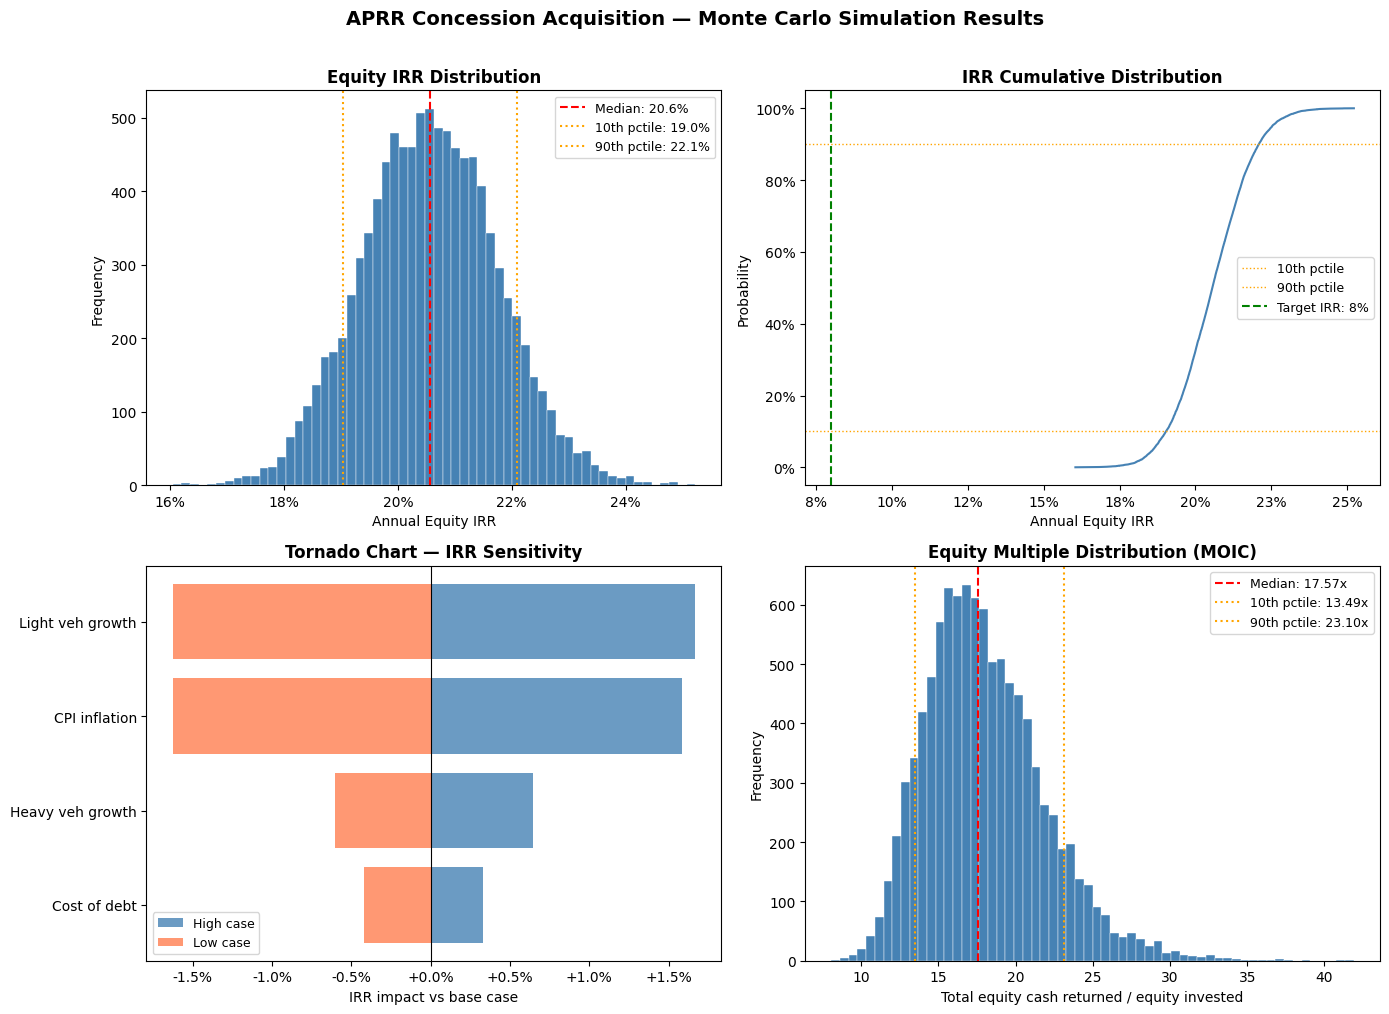

Chart saved as APRR_simulation_outputs.png


In [22]:
# ── 5.1 Simulation Outputs — 2×2 Chart Grid ──────────────────

# ── Tornado chart data ────────────────────────────────────────
tornado_inputs = {
    'Light veh growth':  (LIGHT_VEH_GROWTH_RATE_PA, 0.010),
    'Heavy veh growth':  (HEAVY_VEH_GROWTH_RATE_PA, 0.010),
    'CPI inflation':     (CPI_RATE_PA,               0.008),
    'Cost of debt':      (INTEREST_RATE_PA,           0.007),
}

tornado_results = {}
for label, (base, sd) in tornado_inputs.items():
    args_low  = [LIGHT_VEH_GROWTH_RATE_PA, HEAVY_VEH_GROWTH_RATE_PA, CPI_RATE_PA, INTEREST_RATE_PA]
    args_high = [LIGHT_VEH_GROWTH_RATE_PA, HEAVY_VEH_GROWTH_RATE_PA, CPI_RATE_PA, INTEREST_RATE_PA]
    idx = list(tornado_inputs.keys()).index(label)
    args_low[idx]  = base - 2 * sd
    args_high[idx] = base + 2 * sd
    irr_low,  _, _ = run_model(*args_low)
    irr_high, _, _ = run_model(*args_high)
    tornado_results[label] = (irr_low, irr_high)

tornado_sorted = sorted(tornado_results.items(),
                        key=lambda x: abs(x[1][1] - x[1][0]),
                        reverse=False)

# ── Build 2×2 figure ─────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('APRR Concession Acquisition — Monte Carlo Simulation Results',
             fontsize=14, fontweight='bold', y=1.01)

base_irr = np.median(irrs)

# ── Chart 1: IRR Histogram ────────────────────────────────────
ax1 = axes[0, 0]
ax1.hist(irrs, bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
ax1.axvline(base_irr, color='red', linestyle='--', linewidth=1.5,
            label=f'Median: {base_irr:.1%}')
ax1.axvline(np.percentile(irrs, 10), color='orange', linestyle=':', linewidth=1.5,
            label=f'10th pctile: {np.percentile(irrs, 10):.1%}')
ax1.axvline(np.percentile(irrs, 90), color='orange', linestyle=':', linewidth=1.5,
            label=f'90th pctile: {np.percentile(irrs, 90):.1%}')
ax1.set_title('Equity IRR Distribution', fontweight='bold')
ax1.set_xlabel('Annual Equity IRR')
ax1.set_ylabel('Frequency')
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax1.legend(fontsize=9)

# ── Chart 2: IRR Cumulative Distribution ─────────────────────
ax2 = axes[0, 1]
sorted_irrs = np.sort(irrs)
cumulative  = np.arange(1, len(sorted_irrs) + 1) / len(sorted_irrs)
ax2.plot(sorted_irrs, cumulative, color='steelblue', linewidth=1.5)
ax2.axhline(0.10, color='orange', linestyle=':', linewidth=1, label='10th pctile')
ax2.axhline(0.90, color='orange', linestyle=':', linewidth=1, label='90th pctile')
ax2.axvline(TARGET_EQUITY_IRR, color='green', linestyle='--', linewidth=1.5,
            label=f'Target IRR: {TARGET_EQUITY_IRR:.0%}')
ax2.set_title('IRR Cumulative Distribution', fontweight='bold')
ax2.set_xlabel('Annual Equity IRR')
ax2.set_ylabel('Probability')
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax2.legend(fontsize=9)

# ── Chart 3: Tornado Chart ────────────────────────────────────
ax3 = axes[1, 0]
labels = [item[0] for item in tornado_sorted]
lows   = [item[1][0] - base_irr for item in tornado_sorted]
highs  = [item[1][1] - base_irr for item in tornado_sorted]
y_pos  = range(len(labels))
ax3.barh(y_pos, highs, left=0, color='steelblue', alpha=0.8, label='High case')
ax3.barh(y_pos, lows,  left=0, color='coral',     alpha=0.8, label='Low case')
ax3.axvline(0, color='black', linewidth=0.8)
ax3.set_yticks(y_pos)
ax3.set_yticklabels(labels)
ax3.set_title('Tornado Chart — IRR Sensitivity', fontweight='bold')
ax3.set_xlabel('IRR impact vs base case')
ax3.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:+.1%}'))
ax3.legend(fontsize=9)

# ── Chart 4: Equity Multiple (MOIC) Distribution ─────────────
ax4 = axes[1, 1]
ax4.hist(eq_multiples, bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
ax4.axvline(np.median(eq_multiples), color='red', linestyle='--', linewidth=1.5,
            label=f'Median: {np.median(eq_multiples):.2f}x')
ax4.axvline(np.percentile(eq_multiples, 10), color='orange', linestyle=':', linewidth=1.5,
            label=f'10th pctile: {np.percentile(eq_multiples, 10):.2f}x')
ax4.axvline(np.percentile(eq_multiples, 90), color='orange', linestyle=':', linewidth=1.5,
            label=f'90th pctile: {np.percentile(eq_multiples, 90):.2f}x')
ax4.set_title('Equity Multiple Distribution (MOIC)', fontweight='bold')
ax4.set_xlabel('Total equity cash returned / equity invested')
ax4.set_ylabel('Frequency')
ax4.legend(fontsize=9)

plt.tight_layout()
plt.savefig('APRR_simulation_outputs.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as APRR_simulation_outputs.png")